In [ ]:
!pip install chainladder

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


In [ ]:
import chainladder as cl

tri = cl.load_sample('raa')       # a classic public run-off triangle
print(tri)                        # cumulative claims by origin year and development age
print(tri.link_ratio)             # age-to-age factors

         12       24       36       48       60       72       84       96       108      120
1981  5012.0   8269.0  10907.0  11805.0  13539.0  16181.0  18009.0  18608.0  18662.0  18834.0
1982   106.0   4285.0   5396.0  10666.0  13782.0  15599.0  15496.0  16169.0  16704.0      NaN
1983  3410.0   8992.0  13873.0  16141.0  18735.0  22214.0  22863.0  23466.0      NaN      NaN
1984  5655.0  11555.0  15766.0  21266.0  23425.0  26083.0  27067.0      NaN      NaN      NaN
1985  1092.0   9565.0  15836.0  22169.0  25955.0  26180.0      NaN      NaN      NaN      NaN
1986  1513.0   6445.0  11702.0  12935.0  15852.0      NaN      NaN      NaN      NaN      NaN
1987   557.0   4020.0  10946.0  12314.0      NaN      NaN      NaN      NaN      NaN      NaN
1988  1351.0   6947.0  13112.0      NaN      NaN      NaN      NaN      NaN      NaN      NaN
1989  3133.0   5395.0      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN
1990  2063.0      NaN      NaN      NaN      NaN      NaN   

In [ ]:
model = cl.Chainladder().fit(tri)
print(model.ldf_)                 # selected development factors
print(model.ultimate_)            # ultimate claims per origin year
print(model.ibnr_)                # reserve needed per origin year

          12-24     24-36     36-48     48-60     60-72     72-84     84-96    96-108   108-120  120-132  132-144
(All)  2.999359  1.623523  1.270888  1.171675  1.113385  1.041935  1.033264  1.016936  1.009217      1.0      1.0
              2261
1981  18834.000000
1982  16857.953917
1983  24083.370924
1984  28703.142163
1985  28926.736343
1986  19501.103184
1987  17749.302590
1988  24019.192510
1989  16044.984101
1990  18402.442529
              2261
1981           NaN
1982    153.953917
1983    617.370924
1984   1636.142163
1985   2746.736343
1986   3649.103184
1987   5435.302590
1988  10907.192510
1989  10649.984101
1990  16339.442529


In [ ]:
cl_ult = cl.Chainladder().fit(tri).ultimate_
apriori = cl_ult * 0 + (cl_ult.sum() / 10)      # average ultimate as the prior
bf = cl.BornhuetterFerguson(apriori=1).fit(tri, sample_weight=apriori)
print(bf.ibnr_)

              2261
1981           NaN
1982    194.632172
1983    546.333266
1984   1214.843524
1985   2023.700714
1986   3988.005163
1987   6526.362337
1988   9677.948877
1989  14146.155136
1990  18923.022826


In [ ]:
print(tri)

         12       24       36       48       60       72       84       96       108      120
1981  5012.0   8269.0  10907.0  11805.0  13539.0  16181.0  18009.0  18608.0  18662.0  18834.0
1982   106.0   4285.0   5396.0  10666.0  13782.0  15599.0  15496.0  16169.0  16704.0      NaN
1983  3410.0   8992.0  13873.0  16141.0  18735.0  22214.0  22863.0  23466.0      NaN      NaN
1984  5655.0  11555.0  15766.0  21266.0  23425.0  26083.0  27067.0      NaN      NaN      NaN
1985  1092.0   9565.0  15836.0  22169.0  25955.0  26180.0      NaN      NaN      NaN      NaN
1986  1513.0   6445.0  11702.0  12935.0  15852.0      NaN      NaN      NaN      NaN      NaN
1987   557.0   4020.0  10946.0  12314.0      NaN      NaN      NaN      NaN      NaN      NaN
1988  1351.0   6947.0  13112.0      NaN      NaN      NaN      NaN      NaN      NaN      NaN
1989  3133.0   5395.0      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN
1990  2063.0      NaN      NaN      NaN      NaN      NaN   

In [ ]:
dev = cl.Development().fit(tri)
print(dev.ldf_)

          12-24     24-36     36-48     48-60     60-72     72-84     84-96    96-108   108-120
(All)  2.999359  1.623523  1.270888  1.171675  1.113385  1.041935  1.033264  1.016936  1.009217


In [ ]:
print("Chain ladder total:", model.ibnr_.sum())
print("BF total:", bf.ibnr_.sum())

Chain ladder total: 52135.228261210155
BF total: 57241.00401440586


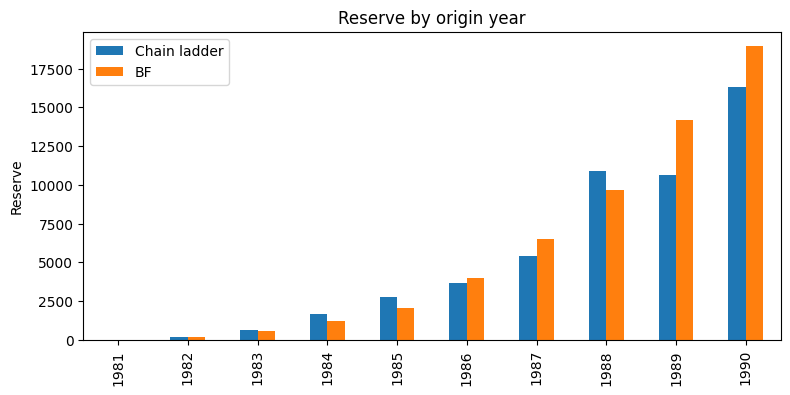

In [10]:
import pandas as pd
years = list(range(1981, 1991))
cl_res = [0, 154, 617, 1636, 2747, 3649, 5435, 10907, 10650, 16339]
bf_res = [0, 195, 546, 1215, 2024, 3988, 6526, 9678, 14146, 18923]

df = pd.DataFrame({"Chain ladder": cl_res, "BF": bf_res}, index=years)
ax = df.plot(kind="bar", figsize=(9, 4), title="Reserve by origin year")
ax.set_ylabel("Reserve")
ax.figure.savefig("reserves.png", bbox_inches="tight")